In [1]:
# importando o dataset do fer2013
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

Using Colab cache for faster access to the 'fer2013' dataset.


In [2]:
!pip install tensorflow

In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import tensorflow
import os

In [4]:
from tensorflow.keras.utils import image_dataset_from_directory

In [5]:
# caminhos para o diretório de teste e treino
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

In [6]:
# parametros para as imagens
batch_size = 64
img_size = (48, 48)

# utilizando a funcao propria do tensorflow para carregar as imagens em um dataset
train_dataset = image_dataset_from_directory(
    train_dir,
    color_mode='grayscale',
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=True
)

test_dataset = image_dataset_from_directory(
    test_dir,
    color_mode='grayscale',
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [7]:
# vendo o formato dos dados
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float32, name=None))>

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense, GlobalAveragePooling2D, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [9]:
# usando o prefetch para acelerar o processamento no colab
train_dataset_ready = train_dataset.prefetch(buffer_size=tensorflow.data.AUTOTUNE)
test_dataset_ready = test_dataset.prefetch(buffer_size=tensorflow.data.AUTOTUNE)

In [10]:
num_labels = 7
epochs = 100
width, height = 48, 48

# instanciando o modeloa
model = Sequential()

# Bloco 1
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=(width, height, 1)))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Bloco 2
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Bloco 3
model.add(Conv2D(128, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(Conv2D(128, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

# Bloco 4
model.add(Conv2D(256, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.4))

# Camadas Densas de Classificação
model.add(Dense(128))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.5))
model.add(Dense(num_labels, activation='softmax'))

# Visualizar o resumo da nova estrutura
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12, 12, 128)    │             

 Total params: 618,215 (2.36 MB)

 Trainable params: 616,807 (2.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [11]:
# otimizador personalizado
adam = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
# compilando
model.compile(
    loss='categorical_crossentropy',
    optimizer=adam,
    metrics=['accuracy']
)

In [12]:
# Arquivos para salvar o modelo treinado e a arquitetura
model_file = 'model.h5'
model_file_json = 'model.json'

model_json = model.to_json()
with open(model_file_json, 'w') as json_file:
    json_file.write(model_json)

In [13]:
# definindo os callbacks
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1, mode='auto')
checkpointer = ModelCheckpoint(model_file, monitor='val_loss', verbose=1, save_best_only=True)

In [14]:
# treinamento do modelo
history = model.fit(
    train_dataset_ready,
    epochs=epochs,
    verbose=1,
    validation_data=test_dataset_ready,
    callbacks=[lr_reducer, early_stopper, checkpointer]
)

Epoch 1/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.2460 - loss: 1.8387
Epoch 1: val_loss improved from None to 2.41683, saving model to model.h5



Epoch 1: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 85s 155ms/step - accuracy: 0.2998 - loss: 1.7231 - val_accuracy: 0.3136 - val_loss: 2.4168 - learning_rate: 0.0010
Epoch 2/100
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4110 - loss: 1.5087
Epoch 2: val_loss improved from 2.41683 to 1.58924, saving model to model.h5



Epoch 2: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.4321 - loss: 1.4683 - val_accuracy: 0.3799 - val_loss: 1.5892 - learning_rate: 0.0010
Epoch 3/100
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4699 - loss: 1.3831
Epoch 3: val_loss improved from 1.58924 to 1.36290, saving model to model.h5



Epoch 3: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.4832 - loss: 1.3584 - val_accuracy: 0.4769 - val_loss: 1.3629 - learning_rate: 0.0010
Epoch 4/100
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4931 - loss: 1.3146
Epoch 4: val_loss improved from 1.36290 to 1.34582, saving model to model.h5



Epoch 4: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.5040 - loss: 1.2915 - val_accuracy: 0.4944 - val_loss: 1.3458 - learning_rate: 0.0010
Epoch 5/100
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5238 - loss: 1.2582
Epoch 5: val_loss improved from 1.34582 to 1.24610, saving model to model.h5


...


Epoch 14: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6389 - loss: 0.9637 - val_accuracy: 0.6141 - val_loss: 1.0428 - learning_rate: 5.0000e-04
Epoch 15/100
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6437 - loss: 0.9446
Epoch 15: val_loss improved from 1.04277 to 1.01259, saving model to model.h5



Epoch 15: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6461 - loss: 0.9393 - val_accuracy: 0.6193 - val_loss: 1.0126 - learning_rate: 5.0000e-04
Epoch 16/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6540 - loss: 0.9276
Epoch 16: val_loss improved from 1.01259 to 0.99620, saving model to model.h5



Epoch 16: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6558 - loss: 0.9224 - val_accuracy: 0.6261 - val_loss: 0.9962 - learning_rate: 5.0000e-04
Epoch 17/100
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6575 - loss: 0.9222
Epoch 17: val_loss did not improve from 0.99620
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6609 - loss: 0.9132 - val_accuracy: 0.6318 - val_loss: 0.9996 - learning_rate: 5.0000e-04
Epoch 18/100
446/449 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6621 - loss: 0.9033
Epoch 18: val_loss did not improve from 0.99620
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.6624 - loss: 0.8988 - val_accuracy: 0.6266 - val_loss: 1.0219 - learning_rate: 5.0000e-04
Epoch 19/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6683 - loss: 0.8847
Epoch 19: val_loss improved from 0.99620 to 0.99224, saving model to model.h5



Epoch 19: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6685 - loss: 0.8821 - val_accuracy: 0.6376 - val_loss: 0.9922 - learning_rate: 5.0000e-04
Epoch 20/100
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6697 - loss: 0.8794
Epoch 20: val_loss improved from 0.99224 to 0.96883, saving model to model.h5



Epoch 20: finished saving model to model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6745 - loss: 0.8704 - val_accuracy: 0.6420 - val_loss: 0.9688 - learning_rate: 5.0000e-04
Epoch 21/100
446/449 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6795 - loss: 0.8618
Epoch 21: val_loss did not improve from 0.96883
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.6821 - loss: 0.8561 - val_accuracy: 0.6383 - val_loss: 0.9801 - learning_rate: 5.0000e-04
Epoch 22/100
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6825 - loss: 0.8576
Epoch 22: val_loss did not improve from 0.96883
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.6842 - loss: 0.8502 - val_accuracy: 0.6403 - val_loss: 0.9903 - learning_rate: 5.0000e-04
Epoch 23/100
446/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6894 - loss: 0.8276
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: val_loss did not improve from 0.96883
449/449 ━━━━━━━━━━━━━━━━━

In [15]:
# historico do treinamento
print(history.history)

{'accuracy': [0.29983627796173096, 0.43212929368019104, 0.48315858840942383, 0.5040231347084045, 0.5286495685577393, 0.5500017404556274, 0.5601031184196472, 0.574662983417511, 0.5835452079772949, 0.5919398069381714, 0.6061514019966125, 0.6118987202644348, 0.6202584505081177, 0.638893723487854, 0.6461388468742371, 0.6557874083518982, 0.6609077453613281, 0.6623706817626953, 0.668466329574585, 0.6745271682739258, 0.6821205615997314, 0.6842453479766846, 0.6875544190406799, 0.700721025466919, 0.7060155272483826, 0.7077919840812683, 0.7212372422218323, 0.7229440212249756, 0.7246159911155701, 0.7271935343742371], 'loss': [1.7230995893478394, 1.4683181047439575, 1.3583976030349731, 1.2914507389068604, 1.2369850873947144, 1.1904795169830322, 1.1618703603744507, 1.1292667388916016, 1.1018792390823364, 1.0867791175842285, 1.0529425144195557, 1.0339890718460083, 1.0149304866790771, 0.9637143015861511, 0.9392904043197632, 0.922350287437439, 0.9131686091423035, 0.8987934589385986, 0.8820647597312927

In [16]:
import matplotlib.pyplot as plt

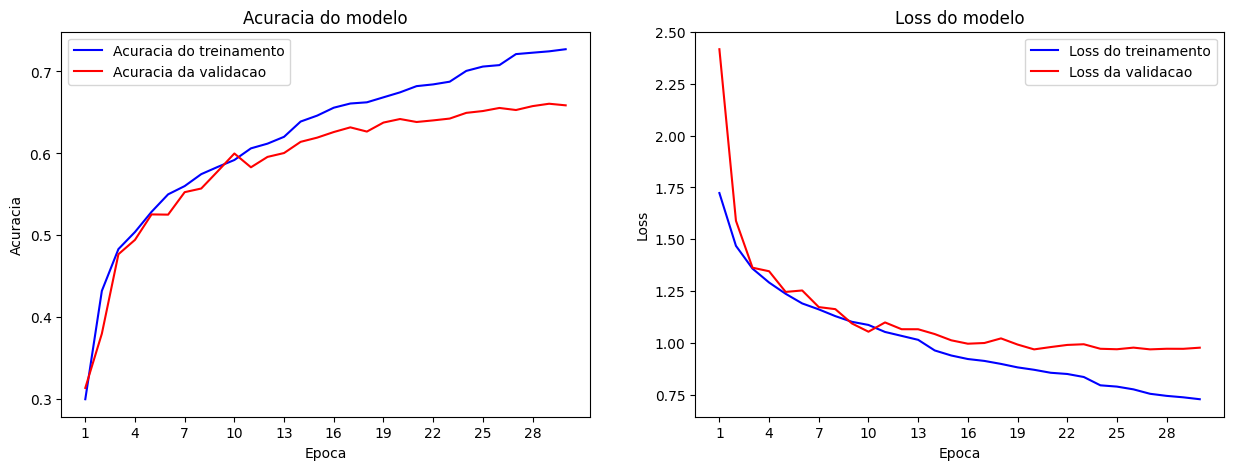

In [19]:
# Criar grafico com historico do modelo
def plot_history_model(history_model):
    fig, axs = plt.subplots(1,2, figsize=(15,5))

    # grafico da acuracia
    axs[0].plot(range(1, len(history_model.history['accuracy']) + 1), history_model.history['accuracy'], 'b')
    axs[0].plot(range(1, len(history_model.history['val_accuracy']) + 1), history_model.history['val_accuracy'], 'r')
    axs[0].set_title('Acuracia do modelo')
    axs[0].set_ylabel('Acuracia')
    axs[0].set_xlabel('Epoca')
    axs[0].set_xticks(np.arange(1, len(history_model.history['accuracy']) + 1,
                                len(history_model.history['accuracy']) / 10))
    axs[0].legend(['Acuracia do treinamento', 'Acuracia da validacao'], loc='best')

    # grafico da loss
    axs[1].plot(range(1, len(history_model.history['loss']) + 1), history_model.history['loss'], 'b')
    axs[1].plot(range(1, len(history_model.history['val_loss']) + 1), history_model.history['val_loss'], 'r')
    axs[1].set_title('Loss do modelo')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoca')
    axs[1].set_xticks(np.arange(1, len(history_model.history['loss']) + 1,
                                len(history_model.history['loss']) / 10))
    axs[1].legend(['Loss do treinamento', 'Loss da validacao'], loc='best')

    # salva a imagem do grafico
    fig.savefig('history_model_mod01.png')

plot_history_model(history)

In [23]:
# vendo as pontuações do modelo
scores = model.evaluate(test_dataset_ready)
print(f"Acuracia: {str(scores[1])}")
print(f"Erro: {str(scores[0])}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6587 - loss: 0.9770
Acuracia: 0.6586793065071106
Erro: 0.9770269989967346


In [24]:
from sklearn.metrics import confusion_matrix
import itertools

In [30]:
# lista das respostas reais
y_true_list = []
for images, labels in test_dataset:
    y_true_list.append(np.argmax(labels.numpy(), axis=1))

# Junta todos os lotes em um único vetor do NumPy
y_true = np.concatenate(y_true_list, axis=0)

In [31]:
# fazendo a previsao dos modelos
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [35]:
# pega o nome das classes
class_names = test_dataset.class_names
class_names

title = 'Confusion Matrix'

In [36]:
# matriz de confusao
cm = confusion_matrix(y_true, y_pred)
cm

array([[ 583,   16,   72,   41,   89,  129,   28],
       [  39,   52,    6,    1,    1,    9,    3],
       [ 131,    8,  393,   35,  111,  215,  131],
       [  42,    0,   25, 1529,   84,   50,   44],
       [  82,    4,   58,   80,  817,  173,   19],
       [ 134,    6,  115,   61,  248,  659,   24],
       [  16,    0,   55,   33,   17,   15,  695]])

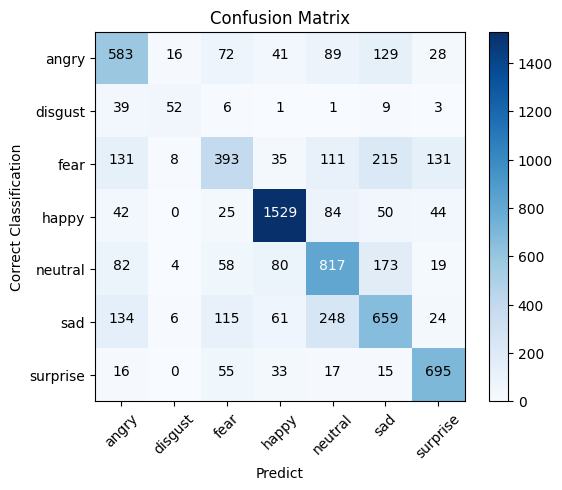

In [37]:
# criando a imagem da matriz de confusão
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(title)
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
fmt = 'd'
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt), horizontalalignment='center', color='white' if cm[i,j] > thresh else 'black')

plt.ylabel('Correct Classification')
plt.xlabel('Predict')
plt.savefig('confusion_matrix.png')